# Análise Estatística do Baseline (Estratégia 1)

Este notebook realiza uma análise profunda dos resultados obtidos pela extração de características 1D (Tempo + Frequência) aliados a modelos clássicos e de Deep Learning Tabular.
Como a tarefa de **Detecção** obteve resultados próximos a 100% de forma unânime, nossa análise estatística focará na tarefa mais desafiadora: o **Diagnóstico Multiclasse**.

**Método Estatístico:**
1. **Teste de Friedman:** Um teste não-paramétrico usado para detectar diferenças nos tratamentos através de múltiplas tentativas de teste (perfeito para comparar modelos de ML em múltiplas dobras).
2. **Teste de Wilcoxon (Post-Hoc):** Caso o teste de Friedman aponte uma diferença significativa, faremos testes pareados para provar que a arquitetura proposta (TabNet) é estatisticamente superior (ou equivalente) aos baselines (Random Forest e SVM).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import friedmanchisquare, wilcoxon

# Configuração de estilo para artigos científicos
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# 1. Carregar os resultados
ARQUIVO_CSV = '../results/resultados_master_strategy1_20260610_103731.csv'
df = pd.read_csv(ARQUIVO_CSV)

# 2. Filtrar apenas a tarefa de Diagnóstico
df_diag = df[df['Task'] == 'Diagnosis'].copy()

# Converter F1 para porcentagem para facilitar a leitura visual
df_diag['Macro F1 (%)'] = df_diag['Macro F1'] * 100

print(f"Total de amostras de diagnóstico (Folds avaliados): {len(df_diag) // 3}")
df_diag.head()

Total de amostras de diagnóstico (Folds avaliados): 21


,Dataset,Task,Fold,Model,Bal Acc,Macro F1,ROC-AUC,Macro F1 (%)
16,CWRU_12k,Diagnosis,Load_0HP,Random Forest,0.825950,0.825698,0.934685,82.569818
17,CWRU_12k,Diagnosis,Load_0HP,SVM (RBF),0.794298,0.792225,0.915481,79.222525
18,CWRU_12k,Diagnosis,Load_0HP,FT-Transformer,0.807675,0.805633,0.929419,80.563349
19,CWRU_12k,Diagnosis,Load_0HP,TabNet,0.826754,0.825905,0.932260,82.590538
20,CWRU_12k,Diagnosis,Load_1HP,Random Forest,0.866082,0.865588,0.974953,86.558754


/tmp/ipykernel_3937/3747819594.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Model', y='Macro F1 (%)', data=df_diag, palette='light:gray', showfliers=False)


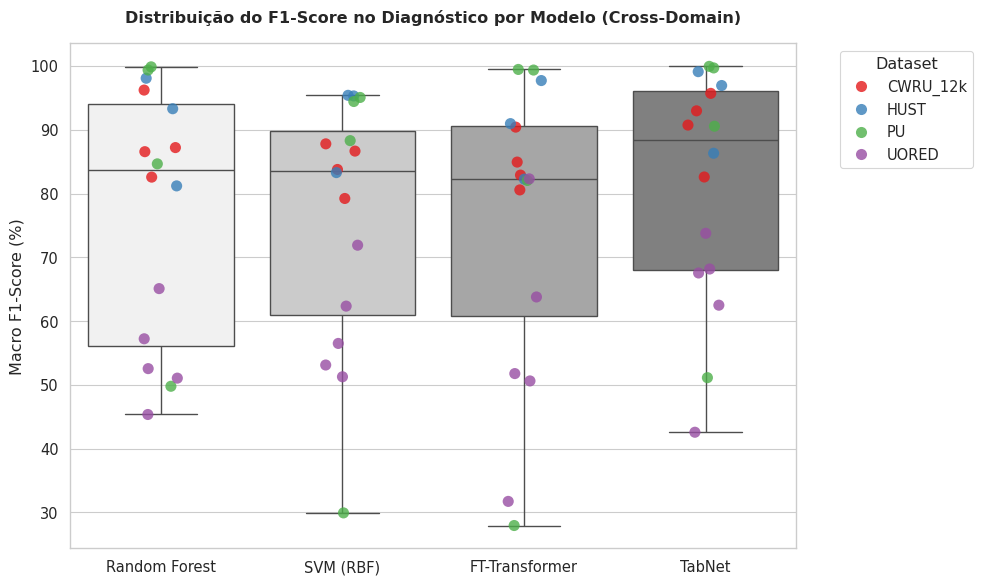

In [2]:
plt.figure(figsize=(10, 6))

# Boxplot para mostrar a mediana e quartis
ax = sns.boxplot(x='Model', y='Macro F1 (%)', data=df_diag, palette='light:gray', showfliers=False)

# Stripplot para mostrar cada fold individualmente como um ponto
sns.stripplot(x='Model', y='Macro F1 (%)', data=df_diag, hue='Dataset', 
              palette='Set1', size=8, alpha=0.8, jitter=True, ax=ax)

plt.title('Distribuição do F1-Score no Diagnóstico por Modelo (Cross-Domain)', pad=15, fontweight='bold')
plt.ylabel('Macro F1-Score (%)')
plt.xlabel('')
plt.legend(title='Dataset', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

### 🔬 Aplicação dos Testes Estatísticos

Para aplicar o Teste de Friedman, precisamos "parear" os resultados. Isso significa que o modelo A, B e C precisam ser comparados exatamente na mesma dobra (ex: fold `Load_0W` da base `HUST`).

In [4]:
# 1. Pivotar a tabela para garantir o pareamento rigoroso
# As linhas serão as dobras e as colunas serão os modelos
df_pareado = df_diag.pivot(index=['Dataset', 'Fold'], columns='Model', values='Macro F1 (%)').dropna()

modelos = ['Random Forest', 'SVM (RBF)', 'TabNet']
print("--- Tabela Pareada de Experimentos (Amostra) ---")
print(df_pareado.head(), "\n")

# 2. Executar o Teste de Friedman
stat_f, p_friedman = friedmanchisquare(
    df_pareado['Random Forest'], 
    df_pareado['SVM (RBF)'], 
    df_pareado['TabNet']
)

print("-" * 50)
print(f"Teste de Friedman | Estatística: {stat_f:.3f} | p-value: {p_friedman:.5f}")

if p_friedman < 0.05:
    print("CONCLUSÃO FRIEDMAN: Existe uma diferença ESTATISTICAMENTE SIGNIFICATIVA entre os 3 modelos (p < 0.05).")
    print("Podemos avançar para o teste Post-Hoc.\n")
    
    # 3. Teste de Wilcoxon Pareado (Comparando com a Proposta TabNet)
    print("--- Teste Post-Hoc de Wilcoxon (TabNet vs Baselines) ---")
    
    # TabNet vs Random Forest
    stat_rf, p_rf = wilcoxon(df_pareado['TabNet'], df_pareado['Random Forest'])
    # TabNet vs SVM
    stat_svm, p_svm = wilcoxon(df_pareado['TabNet'], df_pareado['SVM (RBF)'])
    # TabNet vs FT-Transformer
    stat_ftt, p_ftt = wilcoxon(df_pareado['TabNet'], df_pareado['FT-Transformer'])
    
    print(f"TabNet vs Random Forest : p-value = {p_rf:.5f}")
    if p_rf < 0.05:
        print(" -> TabNet é estatisticamente SUPERIOR ao Random Forest.")
    else:
        print(" -> Não há diferença estatística significativa entre TabNet e Random Forest.")
        
    print(f"\nTabNet vs SVM (RBF)     : p-value = {p_svm:.5f}")
    if p_svm < 0.05:
        print(" -> TabNet é estatisticamente SUPERIOR ao SVM.")
    else:
        print(" -> Não há diferença estatística significativa entre TabNet e SVM.")

    print(f"\nTabNet vs FT-Transformer     : p-value = {p_ftt:.5f}")
    if p_ftt < 0.05:
        print(" -> TabNet é estatisticamente SUPERIOR ao FT-Transformer.")
    else:
        print(" -> Não há diferença estatística significativa entre TabNet e FT-Transformer.")

else:
    print("CONCLUSÃO: Não há diferença estatisticamente significativa entre os modelos. Eles empatam estatisticamente.")
print("-" * 50)

--- Tabela Pareada de Experimentos (Amostra) ---
Model              FT-Transformer  Random Forest  SVM (RBF)     TabNet
Dataset  Fold                                                         
CWRU_12k Load_0HP       80.563349      82.569818  79.222525  82.590538
         Load_1HP       84.927549      86.558754  87.785575  92.960145
         Load_2HP       90.409502      96.216525  86.649254  95.699925
         Load_3HP       82.884129      87.200607  83.769735  90.731379
HUST     Load_0W        82.251400      81.194760  83.277532  86.311854 

--------------------------------------------------
Teste de Friedman | Estatística: 15.875 | p-value: 0.00036
CONCLUSÃO FRIEDMAN: Existe uma diferença ESTATISTICAMENTE SIGNIFICATIVA entre os 3 modelos (p < 0.05).
Podemos avançar para o teste Post-Hoc.

--- Teste Post-Hoc de Wilcoxon (TabNet vs Baselines) ---
TabNet vs Random Forest : p-value = 0.00763
 -> TabNet é estatisticamente SUPERIOR ao Random Forest.

TabNet vs SVM (RBF)     : p-value = 0.00